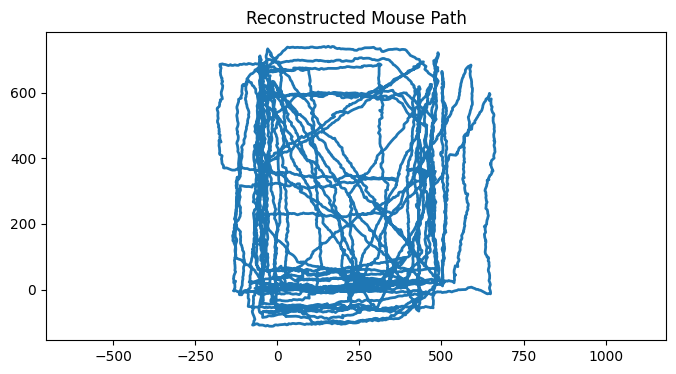

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("mouse_velocities.csv")

# Integrate velocity to get position
df["x"] = df["velocity_x"].cumsum()
df["y"] = df["velocity_y"].cumsum()

plt.figure(figsize=(8, 4))
plt.plot(df["x"], -df["y"], linewidth=2)  # inverting  Y so it looks like screen coordinates
plt.axis("equal")
plt.title("Reconstructed Mouse Path")
plt.show()


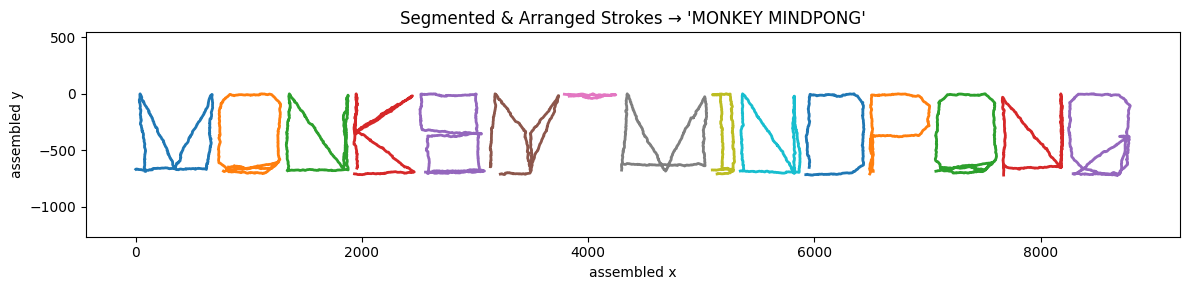

Total letters detected: 15


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("mouse_velocities.csv")
dx = df["velocity_x"].to_numpy()
dy = df["velocity_y"].to_numpy()

x = np.cumsum(dx)
y = np.cumsum(dy)

speed = np.hypot(dx, dy)
low = speed < 1.0
min_pause_len = 25
pauses = []
count = 0
for i, v in enumerate(low):
    if v:
        count += 1
    else:
        if count >= min_pause_len:
            pauses.append(i - count // 2)
        count = 0
if count >= min_pause_len:
    pauses.append(len(low) - count // 2)


cuts = [0] + pauses + [len(x)]
segments = [(cuts[i], cuts[i+1]) for i in range(len(cuts)-1)]
segments = [seg for seg in segments if seg[1]-seg[0] > 50]


kerning = 50
offset = 0
colors = plt.cm.tab10.colors
plt.figure(figsize=(12,3))
for i, (a,b) in enumerate(segments):
    xs = x[a:b] - x[a]
    ys = y[a:b] - y[a]
    xs -= xs.min()
    ys -= ys.min()
    xs += offset
    plt.plot(xs, -ys, color=colors[i % len(colors)], linewidth=2)
    offset = xs.max() + kerning

plt.axis("equal")
plt.title("Segmented & Arranged Strokes → 'MONKEY MINDPONG'")
plt.xlabel("assembled x")
plt.ylabel("assembled y")
plt.tight_layout()
plt.show()

print(f"Total letters detected: {len(segments)}")
